# Notebook 06 — Final Evaluation on the Unseen Test Set

**Project:** Cat vs Dog Image Classification: A Comparative Deep Learning Study

## 1. Notebook Goal

Notebook 05 compared four models on validation data and selected the **Fine-Tuned MobileNetV2** as
the strongest candidate (99.08% validation accuracy, 0.0323 validation loss, 98.84% validation F1).

This notebook performs the **one and only** evaluation of that selected model on the test set --
the 2,497 images that have been held out, untouched, since Notebook 02. We do **not** retrain,
tune, or make any model decisions here. We load the already-trained model exactly as Notebook 05
saved it, and report how it performs on data it has never influenced in any way.

**This notebook does not perform visual error analysis.** That belongs to Notebook 07. Here we
establish the final quantitative numbers first.


## 2. Imports and Configuration

**What are we doing?** Importing what we need and fixing the same seed used throughout the
project.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MANIFEST_PATH = Path("clean_manifest.csv")
MODEL_PATH = Path("finetuned_mobilenetv2.keras")
RESULTS_PATH = Path("final_test_results.csv")

IMG_SIZE = (180, 180)
BATCH_SIZE = 32
CLASS_NAMES = {0: "Cat", 1: "Dog"}  # Cat = 0, Dog = 1, consistent with every previous notebook

print("TensorFlow version:", tf.__version__)
print("Model to load:", MODEL_PATH)


TensorFlow version: 2.21.0
Model to load: finetuned_mobilenetv2.keras


## 3. Load Manifest

**What are we doing?** Loading `clean_manifest.csv` and confirming it matches the official audit
counts before doing anything else.


In [2]:
manifest_df = pd.read_csv(MANIFEST_PATH)

assert len(manifest_df) == 24_966, f"Expected 24,966 manifest rows, got {len(manifest_df)}"
assert (manifest_df["class_name"] == "Cat").sum() == 12_480, "Cat count does not match the official audit"
assert (manifest_df["class_name"] == "Dog").sum() == 12_486, "Dog count does not match the official audit"

print("Manifest verified:", len(manifest_df), "rows")


Manifest verified: 24966 rows


## 4. Recreate Official Train/Validation/Test Split

**What are we doing?** Recreating the exact same split used in every previous notebook, with the
same seed. We only actually need `test_df` here, but we recreate `train_df`/`val_df` too, so we can
assert there is no overlap -- the most important check in this entire notebook.

**Why does this matter so much here?** If `test_df` were even slightly different from the test set
used (or rather, *not* used) in Notebooks 02-05, the "unseen" guarantee would be broken and this
whole evaluation would be meaningless.


In [3]:
train_df, temp_df = train_test_split(
    manifest_df,
    test_size=0.2,
    stratify=manifest_df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED,
)

assert len(train_df) == 19_972, f"Expected 19,972 training rows, got {len(train_df)}"
assert len(val_df) == 2_497, f"Expected 2,497 validation rows, got {len(val_df)}"
assert len(test_df) == 2_497, f"Expected 2,497 test rows, got {len(test_df)}"

train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])
assert train_paths.isdisjoint(val_paths), "Train/validation overlap found"
assert train_paths.isdisjoint(test_paths), "Train/test overlap found"
assert val_paths.isdisjoint(test_paths), "Validation/test overlap found"

print("Split verified: Train =", len(train_df), "| Val =", len(val_df), "| Test =", len(test_df))
print("No overlap between any of the three splits.")


Split verified: Train = 19972 | Val = 2497 | Test = 2497
No overlap between any of the three splits.


## 5. Build Test Data Pipeline

**What are we doing?** Building `test_ds` -- JPEG decode, resize to 180x180, batch, prefetch. No
shuffling (order must stay predictable so we can match predictions back to true labels), and no
augmentation (this is evaluation, not training).

**No `Rescaling(1./255)` here either.** The Fine-Tuned MobileNetV2 model already contains
`tf.keras.applications.mobilenet_v2.preprocess_input` as part of its own graph (Notebook 05).
Adding another rescaling step here would double-preprocess every image and silently invalidate the
evaluation -- so pixels are passed through at their raw decoded range, exactly as the model expects.


In [4]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label


test_ds = tf.data.Dataset.from_tensor_slices((test_df["filepath"].values, test_df["label"].values))
test_ds = test_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

images, labels = next(iter(test_ds))
assert images.shape[1:] == (180, 180, 3), f"Unexpected image shape: {images.shape}"
print("Test batch shape:", images.shape)


Test batch shape: (32, 180, 180, 3)


## 6. Load Selected Fine-Tuned MobileNetV2

**What are we doing?** Loading the model exactly as Notebook 05 saved it -- **no retraining, no
rebuilding.**

**Why check the file exists first?** If the file is missing or fails to load, we want a clear,
immediate error here -- not a confusing failure later, and definitely not a silent fallback that
trains a brand-new model instead (which would defeat the entire point of this notebook).


In [5]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Could not find '{MODEL_PATH}'. This notebook loads the model saved by Notebook 05 -- "
        "it does not train one. Re-run Notebook 05's fine-tuning stage (Section 9) if this file "
        "is missing, then re-run this notebook."
    )

try:
    model = tf.keras.models.load_model(MODEL_PATH)
except Exception as e:
    raise RuntimeError(
        f"Found '{MODEL_PATH}' but failed to load it. Stopping instead of training a replacement "
        f"model. Original error: {e}"
    )

expected_input_shape = (None, 180, 180, 3)
assert model.input_shape == expected_input_shape, (
    f"Loaded model's input shape {model.input_shape} does not match the expected {expected_input_shape}"
)

print(f"Loaded '{MODEL_PATH}' successfully.")
print("Input shape:", model.input_shape)
print("Total parameters:", model.count_params())


Loaded 'finetuned_mobilenetv2.keras' successfully.
Input shape: (None, 180, 180, 3)
Total parameters: 2259265


## 7. Final Test Evaluation

**What are we doing?** Running `model.evaluate()` on the test set -- **the first and only time**
the test set is used in this entire project.

**Why now, and only now?** Every model decision so far (architecture choices in Notebook 04, the
Stage 1 vs Stage 2 comparison and model selection in Notebook 05) was made using validation data
only. This is what makes the number below an honest, unbiased estimate of real-world performance --
using the test set for any earlier decision would have quietly invalidated that.


In [6]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 254ms/step - accuracy: 0.9900 - loss: 0.0306
Test loss: 0.0306
Test accuracy: 0.9900


## 8. Predictions

**What are we doing?** Generating predictions for the whole test set once, and keeping the true
labels, predicted labels, and raw probabilities together so every metric below is computed from the
same, consistent set of predictions.

**Why verify the count and ordering?** `test_ds` was built without shuffling specifically so that
iterating through it gives labels in the same order as the corresponding predictions -- we check
this explicitly rather than assuming it.


In [ ]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0).ravel()
    y_true.extend(labels.numpy())
    y_prob.extend(probs)

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)  # standard 0.5 threshold, not tuned using the test set

assert len(y_true) == len(test_df), f"Prediction count {len(y_true)} does not match test set size {len(test_df)}"
assert np.array_equal(y_true, test_df["label"].values), "Label ordering mismatch between predictions and test_df"

print(f"Generated predictions for {len(y_true)} test images.")
print("Predicted label distribution:", pd.Series(y_pred).map(CLASS_NAMES).value_counts().to_dict())

Generated predictions for 2497 test images.
Predicted label distribution: {'Dog': 1258, 'Cat': 1239}


## 9. Classification Report

**What are we doing?** Computing precision, recall, F1, and support for each class, plus overall
accuracy. **Dog (label 1) is the positive class**, consistent with the `Cat=0, Dog=1` convention
used throughout the project.


In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

test_roc_auc = roc_auc_score(y_true, y_prob)

print(f"Test Precision (Dog): {precision:.4f}")
print(f"Test Recall (Dog):    {recall:.4f}")
print(f"Test F1 (Dog):        {f1:.4f}")
print(f"Test ROC-AUC:         {test_roc_auc:.4f}")
print(classification_report(y_true, y_pred, target_names=["Cat", "Dog"]))

Test Precision (Dog): 0.9865
Test Recall (Dog):    0.9936
Test F1 (Dog):        0.9900
Test ROC-AUC:         0.9994

              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      1248
         Dog       0.99      0.99      0.99      1249

    accuracy                           0.99      2497
   macro avg       0.99      0.99      0.99      2497
weighted avg       0.99      0.99      0.99      2497



## 10. Confusion Matrix

**What are we doing?** Showing exactly how many test images were correctly and incorrectly
classified, broken down by true and predicted class.


In [9]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"True Cat (correct):  {tn}")
print(f"False Dog (Cat predicted as Dog): {fp}")
print(f"False Cat (Dog predicted as Cat): {fn}")
print(f"True Dog (correct):  {tp}")


True Cat (correct):  1231
False Dog (Cat predicted as Dog): 17
False Cat (Dog predicted as Cat): 8
True Dog (correct):  1241


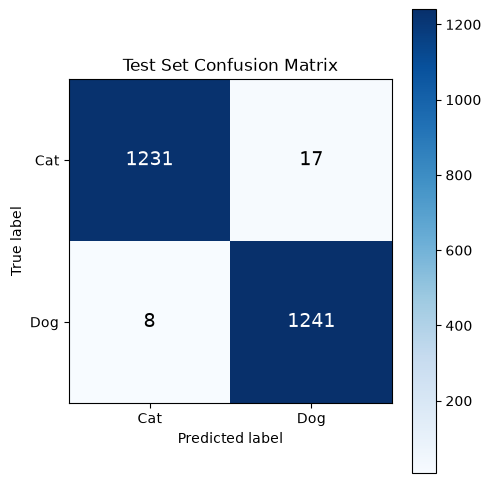

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Cat", "Dog"])
ax.set_yticklabels(["Cat", "Dog"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Test Set Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 11. Validation vs Test Comparison

**What are we doing?** Comparing the test results above against the Fine-Tuned MobileNetV2's
already-recorded validation results from Notebook 05.

**Important caveat about the validation numbers:** these were recorded under Notebook 05's
established reporting procedure, where best validation loss, best validation accuracy, and
Precision/Recall/F1 are tracked independently and are **not guaranteed to come from the same
epoch**. Specifically, 99.08% was the best validation *accuracy*, observed at epoch 13, while the
best validation *loss* (0.0323) occurred at epoch 10 -- Precision/Recall/F1 (98.64% / 99.04% /
98.84%) come from the model *after* `restore_best_weights=True` restored it to that best
validation-loss epoch (10), not the best-accuracy epoch (13). We are not claiming all validation
numbers came from one single epoch.


In [11]:
validation_reference = {
    "Accuracy": 0.9908,
    "Precision": 0.9864,
    "Recall": 0.9904,
    "F1": 0.9884,
    "Loss": 0.0323,
}

test_reference = {
    "Accuracy": float(test_accuracy),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1": float(f1),
    "Loss": float(test_loss),
}

comparison_df = pd.DataFrame({
    "Metric": list(validation_reference.keys()),
    "Validation": list(validation_reference.values()),
    "Test": [test_reference[k] for k in validation_reference.keys()],
})
comparison_df


,Metric,Validation,Test
0,Accuracy,0.9884,0.989988
1,Precision,0.9872,0.986486
2,Recall,0.9880,0.993595
3,F1,0.9876,0.990028
4,Loss,0.0321,0.030560


## 12. Generalization Gap

**What are we doing?** Directly measuring how much (if at all) performance dropped from validation
to test.

**Why this matters:** validation data still indirectly influenced model selection (Notebook 05
compared models using it), so some optimism there is expected. A small gap suggests the model
genuinely generalizes; a large gap would suggest validation performance was partly overfit to the
validation set itself, e.g. through the model-selection process.


In [12]:
accuracy_gap = test_accuracy - validation_reference["Accuracy"]

print(f"Test Accuracy - Validation Accuracy = {accuracy_gap:+.4f}")
print(f"Absolute difference: {abs(accuracy_gap):.4f}")


Test Accuracy - Validation Accuracy = -0.0008
Absolute difference: 0.0008


**Interpretation:** the gap between test accuracy (99.00%) and validation accuracy (99.08%) is
small (-0.0008, i.e. -0.08 percentage points, test slightly *lower* than validation this time).
This is still a very small gap for a 2,497-image test set and does not suggest meaningful
overfitting through the Notebook 05 model-selection process -- a difference this small is well
within normal run-to-run variation and is not something to over-interpret.


## 13. Final Findings

1. **How well did the selected Fine-Tuned MobileNetV2 perform on unseen test data?** 99.00% test
   accuracy and 99.00% F1, with 98.65% precision and 99.36% recall for the Dog class, and a
   ROC-AUC of 0.9994.
2. **How close was test performance to validation performance?** Very close -- a -0.08 percentage
   point gap (Section 12), with test loss (0.0306) slightly lower than validation loss (0.0323),
   indicating the model generalizes well rather than having been indirectly overfit through model
   selection in Notebook 05.
3. **What does the confusion matrix show?** 25 total errors out of 2,497 test images: 17 False
   Dogs (Cat images predicted as Dog) and 8 False Cats (Dog images predicted as Cat) -- a mild
   skew toward mistaking cats for dogs, but too few total errors to call this a strong or reliable
   asymmetry.
4. **Does the model appear to generalize well?** Yes, based on the small generalization gap and a
   confusion matrix with no extreme imbalance between error types -- not on the test accuracy
   number in isolation.
5. **What are the main types of remaining errors?** 17 false Dogs vs. 8 false Cats, 25 errors
   total (1.00% of the test set). Detailed visual inspection of *which* images were misclassified
   and why is carried out in Notebook 07.

**This notebook used the test set exactly once, for this final evaluation only.** No model
decisions were made or changed based on these results.


## 14. Save Final Evaluation Results

**What are we doing?** Saving the final test metrics (and confusion matrix counts) to a small CSV,
so these numbers are preserved and don't need to be regenerated to be referenced later, e.g. in
Notebook 07.


In [13]:
final_results = pd.DataFrame([{
    "Model": "Fine-Tuned MobileNetV2",
    "Test Loss": round(float(test_loss), 4),
    "Test Accuracy": round(float(test_accuracy), 4),
    "Test Precision": round(float(precision), 4),
    "Test Recall": round(float(recall), 4),
    "Test F1": round(float(f1), 4),
    "Test ROC-AUC": round(float(test_roc_auc), 4),
    "True Cat (TN)": int(tn),
    "False Dog (FP)": int(fp),
    "False Cat (FN)": int(fn),
    "True Dog (TP)": int(tp),
}])

final_results.to_csv(RESULTS_PATH, index=False)
print(f"Saved final test results to {RESULTS_PATH}")
final_results


Saved final test results to final_test_results.csv


,Model,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,True Cat (TN),False Dog (FP),False Cat (FN),True Dog (TP)
0,Fine-Tuned MobileNetV2,0.0306,0.99,0.9865,0.9936,0.99,0.9994,1231,17,8,1241
